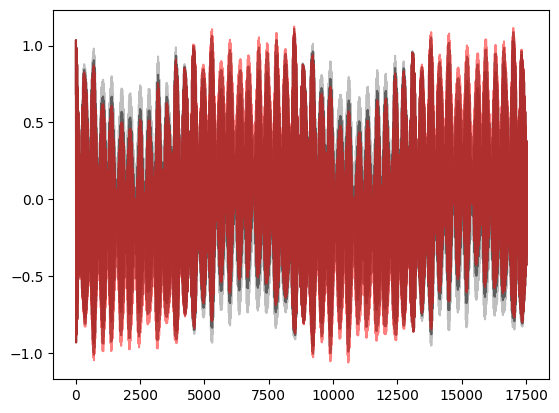

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import pandas as pd
import os

# path_root = "/Users/timhermans/Documents/GitHub/aslc_intertidal"
path_root = "F:/collaborations/Tim_Hermans/aslc_intertidal"
os.chdir(path_root)

import src.functions as f

def add_aslc(time, waterlevel, amplitude_annual_m, phase):

    period_annual_hr = 365.25 * 24
    waterlevel_new = waterlevel + amplitude_annual_m * np.cos(time*2*np.pi/period_annual_hr + phase)

    return waterlevel_new

def create_ticon_timeseries(path_csv, lat, lon):

    def find_tidal_range(w, dt):

        if dt != 5/60:
            # Interpolate to 5 min measuring interval so 745 min tidal interval can be divided evenly
            t = np.arange(0, w.size, 1) * dt
            tp = np.arange(0, t.max(), 5/60)
            w = np.interp(x = tp, xp = t, fp = w)

        # Reshape water level time series into stacked array of n tidal cycles (each 149 measurements long at dt = 5/60)
        n_measurements_per_tide = int((745/60) / (5/60))
        n_tides = int(np.floor(w.size/n_measurements_per_tide))
        w = w[:int(n_tides*n_measurements_per_tide)]
        w = w.reshape(n_tides, n_measurements_per_tide)

        # Calcualte high & low water level of each tidal cycle, and from that calculate the avg. tidal range
        high_water_level = w.max(axis = 1)
        low_water_level = w.min(axis = 1)
        tidal_range = (high_water_level - low_water_level)

        return tidal_range.mean()

    tidal_constants = np.array([
        'M2', 'K1', 'N2', 'O1', 'P1', 'Q1', 'K2', 'S2', 'S1', 'SA', 'T2', 'MF', 'MM',
        '2N2', 'M4', 'J1', 'SSA', 'MSF', 'MSQ', 'EP2', 'L2', 'M3', 'R2', 'MI2', 'MTM',
        'NI2', 'LM2', 'MN4', 'MS4', 'MKS', 'N4', 'M6', 'M8', 'S4', '2Q1', 'OO1', 'S3',
        'MA2', 'MB2', 'M1'
    ])
    period_hr = np.array([
        12.4206, 23.9345, 12.6583, 25.8193, 24.0659, 26.8684, 11.9672, 12.0000, 24.0000,
        8766.0, 12.0160, 327.85, 661.31, 12.9054, 6.2103, 23.0984, 4383.0, 354.37, 6.1328,
        12.3283, 12.1916, 8.2804, 11.8700, 12.8729, 6.1033, 12.8864, 12.6321, 6.2692,
        6.1033, 6.0769, 6.3293, 4.1402, 3.1052, 6.0000, 27.8454, 22.3061, 8.0000, 12.8714,
        12.5660, 23.9340
    ])

    df = pd.read_csv(path_csv, sep='\s+')
    df.columns = ['latitude', 'longitude', 'tidal_constituent', 'amplitude_cm', 'phase_degrees', 'amplitude-std_cm', 'phase-std_degrees', 'missing_data_percent', 'total_observations', 'time_gap_max', 'start_date', 'end_date', 'data_source']

    df['site_id'] = df.groupby(['latitude', 'longitude', 'data_source', 'start_date', 'end_date']).ngroup()
    site_list = np.unique(df['site_id'])
    n_sites = site_list.size

    def closest_to(x0, y0, x1, y1):
        return np.argmin(np.sqrt((x1 - x0)**2 + (y1 - y0)**2))
    idx = closest_to(df['latitude'], df['longitude'],  lat, lon)

    site = df['site_id'] == df['site_id'][idx]
    df_site = df[site]
    df_site.loc[df['tidal_constituent'] == 'SA', 'amplitude_cm'] = 0 
    df_site.loc[df['tidal_constituent'] == 'SSA', 'amplitude_cm'] = 0 
    amplitude_m  = df_site['amplitude_cm'].to_numpy() / 100
    phase_rad  = np.deg2rad(df_site['phase_degrees'].to_numpy())

    n_years = 2
    dt = 5/60
    tf    = 365.25 * 24 * n_years # 1 year (in hours)
    t = np.arange(0, tf + dt, dt)
    
    w = (amplitude_m[np.newaxis, :] * np.cos(t[:, np.newaxis]*2*np.pi/period_hr[np.newaxis, :] + phase_rad[np.newaxis, :])).sum(axis = 1)
    tidal_range = find_tidal_range(w, dt)
    w = w/tidal_range

    return t, w

lat, lon, historical_aslc_ratio, future_aslc_change_ratio, phase = -17.533, -149.573, 0.1578, 0.0724, 0.25*2*np.pi
# lat, lon, historical_aslc_ratio, future_aslc_change_ratio, phase =  41.342,    2.166, 0.4904, 0.1192, 0.70*2*np.pi
# lat, lon, historical_aslc_ratio, future_aslc_change_ratio, phase =  35.548,  133.243, 0.8947, 0.0603, 0.65*2*np.pi

time, waterlevel = create_ticon_timeseries(path_csv = 'data/ticon/TICON.txt', lat = lat, lon = lon)

waterlevel_t0 = add_aslc(time, waterlevel, amplitude_annual_m = historical_aslc_ratio, phase = phase)
waterlevel_t1 = add_aslc(time, waterlevel_t0, amplitude_annual_m = future_aslc_change_ratio, phase = phase)

plt.plot(time, waterlevel, alpha = 0.5, c = 'grey')
plt.plot(time, waterlevel_t0, alpha = 0.5, c = 'black')
plt.plot(time, waterlevel_t1, alpha = 0.5, c = 'red')
plt.show()
